# ANS Perception Pipeline — Verification Notebook
**AI 710 — Principles of Machine Learning**  
**Rochester Institute of Technology — Spring 2026**  
**Team:** Adit Dhall · Thejas Nagesh Gowda · Matthew Landon

This notebook runs on Narnia (or locally) to verify all components of the ANS pipeline.
It does NOT train anything — all training is done via scripts.

**Run order:** Execute cells top to bottom in order.

## 0. Setup — Paths and Imports

In [1]:
import os, sys, json
import numpy as np
import torch

# ── Set repo root ──────────────────────────────────────────────────────────────
# Change this if your repo is in a different location
REPO = os.path.expanduser('~/MARS-ANS')
SRC  = os.path.join(REPO, 'src')
DATA = os.path.join(REPO, 'data')

sys.path.insert(0, SRC)

print(f'Repo root: {REPO}')
print(f'Src path:  {SRC}')
print(f'Data path: {DATA}')
print(f'Repo exists: {os.path.exists(REPO)}')
print(f'Src exists:  {os.path.exists(SRC)}')
print(f'Data exists: {os.path.exists(DATA)}')

Repo root: /home/stu12/s2/ad6449/MARS-ANS
Src path:  /home/stu12/s2/ad6449/MARS-ANS/src
Data path: /home/stu12/s2/ad6449/MARS-ANS/data
Repo exists: True
Src exists:  True
Data exists: True


In [2]:
# ── GPU / Environment check ────────────────────────────────────────────────────
print(f'Python:  {sys.version}')
print(f'PyTorch: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
else:
    print('Running on CPU')

Python:  3.11.15 (main, Mar 11 2026, 17:20:07) [GCC 14.3.0]
PyTorch: 2.5.1+cu121
CUDA available: True
GPU: NVIDIA A16


## 1. Dataset Verification

In [3]:
# ── Check AI4Mars dataset structure ───────────────────────────────────────────
from PIL import Image

IMG_DIR   = os.path.join(DATA, 'ai4mars/ai4mars-dataset-merged-0.1/msl/images/edr')
LABEL_DIR = os.path.join(DATA, 'ai4mars/ai4mars-dataset-merged-0.1/msl/labels/train')
GOOD_JSON = os.path.join(DATA, 'good_labels.json')

print(f'Image dir exists:  {os.path.exists(IMG_DIR)}')
print(f'Label dir exists:  {os.path.exists(LABEL_DIR)}')
print(f'good_labels.json:  {os.path.exists(GOOD_JSON)}')

if os.path.exists(IMG_DIR):
    imgs = [f for f in os.listdir(IMG_DIR) if f.endswith('.JPG')]
    print(f'\nTotal images: {len(imgs)}')

if os.path.exists(LABEL_DIR):
    labels = [f for f in os.listdir(LABEL_DIR) if f.endswith('.png')]
    print(f'Total labels: {len(labels)}')

if os.path.exists(GOOD_JSON):
    with open(GOOD_JSON) as f:
        good = json.load(f)
    print(f'Good labels: {len(good)}')

Image dir exists:  True
Label dir exists:  True
good_labels.json:  True

Total images: 18127
Total labels: 16064
Good labels: 15901


In [4]:
# ── Check label pixel values and class mapping ─────────────────────────────────
class_names = {0: 'soil', 1: 'bedrock', 2: 'sand', 3: 'big_rocks', 255: 'unknown'}

sample_label = os.path.join(LABEL_DIR, good[0])
lbl = np.array(Image.open(sample_label))

print(f'Sample label: {good[0]}')
print(f'Label shape:  {lbl.shape}')
print(f'Unique values: {np.unique(lbl)}')
print()
for v in np.unique(lbl):
    pct = (lbl == v).sum() / lbl.size * 100
    print(f'  {v} ({class_names.get(v, "?")}): {pct:.1f}%')

Sample label: NLA_397681339EDR_F0020000AUT_04096M1.png
Label shape:  (1024, 1024)
Unique values: [  0 255]

  0 (soil): 46.9%
  255 (unknown): 53.1%


In [5]:
# ── Class frequency analysis ───────────────────────────────────────────────────
from collections import Counter

class_pixel_counts = Counter()
sample_size = min(500, len(good))

for fname in good[:sample_size]:
    lbl = np.array(Image.open(os.path.join(LABEL_DIR, fname)))
    for cls_id, cls_name in {0:'soil',1:'bedrock',2:'sand',3:'big_rocks'}.items():
        class_pixel_counts[cls_name] += (lbl == cls_id).sum()

total = sum(class_pixel_counts.values())
print(f'Class frequency in first {sample_size} good labels:')
for cls, cnt in class_pixel_counts.most_common():
    print(f'  {cls:12s}: {cnt:>10,} pixels ({cnt/total*100:.1f}%)')

Class frequency in first 500 good labels:
  soil        : 225,035,638 pixels (81.3%)
  sand        : 47,011,711 pixels (17.0%)
  bedrock     :  3,620,288 pixels (1.3%)
  big_rocks   :  1,007,006 pixels (0.4%)


In [6]:
# ── DataLoader verification ────────────────────────────────────────────────────
from data import get_dataloaders

train_loader, val_loader, test_loader = get_dataloaders(
    IMG_DIR, LABEL_DIR, GOOD_JSON, batch_size=16
)

imgs, labels = next(iter(train_loader))
print(f'Image batch shape:   {imgs.shape}')
print(f'Label batch shape:   {labels.shape}')
print(f'Unique label values: {labels.unique().tolist()}')
print(f'Image value range:   [{imgs.min():.2f}, {imgs.max():.2f}]')
print(f'Train batches: {len(train_loader)}')
print(f'Val batches:   {len(val_loader)}')
print(f'Test batches:  {len(test_loader)}')

Train: 12720, Val: 1590, Test: 1591
Class weights (soil, bedrock, sand, big_rocks): [2.700000047683716, 2.0, 8.300000190734863, 111.0]
Image batch shape:   torch.Size([16, 3, 256, 256])
Label batch shape:   torch.Size([16, 256, 256])
Unique label values: [0, 1, 2, 3, 255]
Image value range:   [-2.12, 2.64]
Train batches: 795
Val batches:   100
Test batches:  100


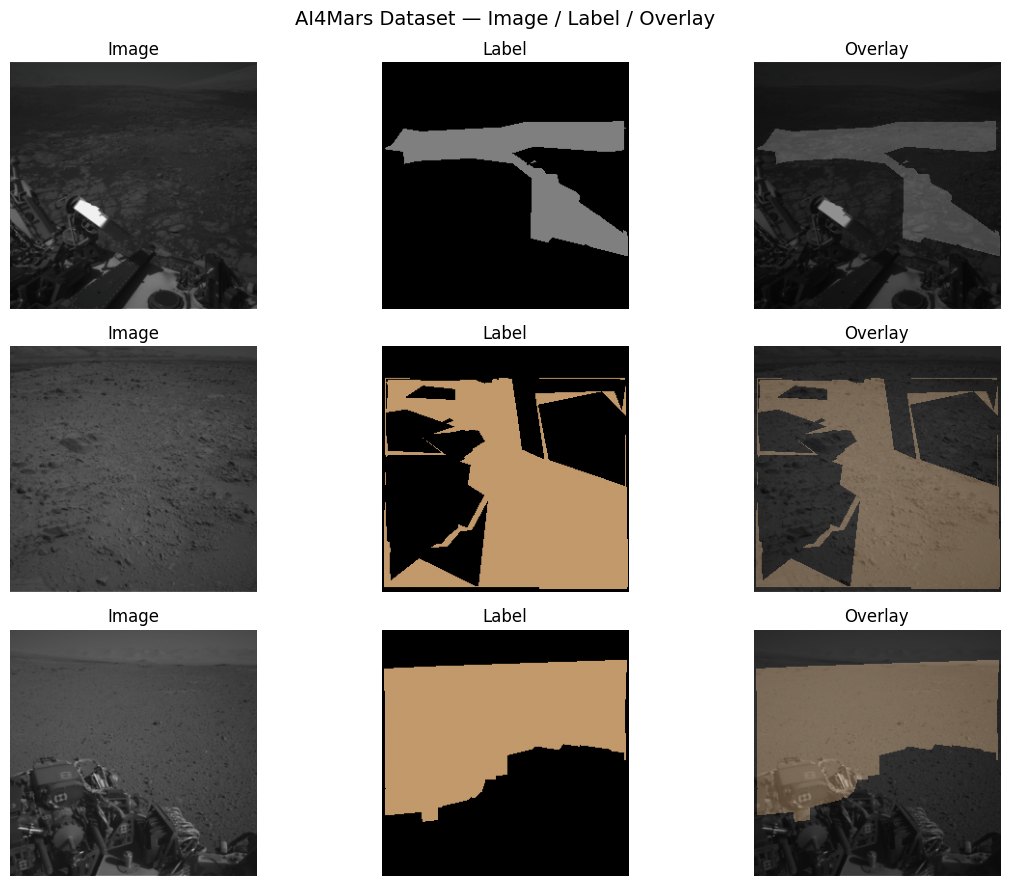

✅ Visual verification complete


In [7]:
# ── Visual label overlay ───────────────────────────────────────────────────────
import matplotlib.pyplot as plt

CLASS_COLORS = {
    0:   ([0.76, 0.60, 0.42], 'soil'),
    1:   ([0.50, 0.50, 0.50], 'bedrock'),
    2:   ([0.87, 0.82, 0.65], 'sand'),
    3:   ([0.60, 0.30, 0.10], 'big_rocks'),
    255: ([0.00, 0.00, 0.00], 'unknown'),
}

def label_to_color(label_np):
    h, w = label_np.shape
    color = np.zeros((h, w, 3))
    for cls_id, (col, _) in CLASS_COLORS.items():
        color[label_np == cls_id] = col
    return color

mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])
def denorm(t):
    return np.clip(t.permute(1,2,0).numpy() * std + mean, 0, 1)

fig, axes = plt.subplots(3, 3, figsize=(12, 9))
for i in range(3):
    img_np    = denorm(imgs[i])
    label_np  = labels[i].numpy()
    color_lbl = label_to_color(label_np)
    overlay   = np.clip(img_np * 0.6 + color_lbl * 0.4, 0, 1)

    axes[i][0].imshow(img_np);    axes[i][0].set_title('Image');   axes[i][0].axis('off')
    axes[i][1].imshow(color_lbl); axes[i][1].set_title('Label');   axes[i][1].axis('off')
    axes[i][2].imshow(overlay);   axes[i][2].set_title('Overlay'); axes[i][2].axis('off')

plt.suptitle('AI4Mars Dataset — Image / Label / Overlay', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(REPO, 'figures/dataset_verification.png'), dpi=100, bbox_inches='tight')
plt.show()
print('✅ Visual verification complete')

## 2. Model Unit Tests

In [8]:
# ── Test: get_dominant_label ───────────────────────────────────────────────────
from perception import TerrainClassifier, get_dominant_label, run_mc_dropout

fake_labels = torch.zeros(4, 256, 256, dtype=torch.long)
fake_labels[0] = 1    # all bedrock
fake_labels[1, :128] = 255  # half unknown, half soil
fake_labels[2] = 3    # all big_rocks
fake_labels[3] = 255  # all unknown → should fallback to 0

result = get_dominant_label(fake_labels).tolist()
print(f'Dominant labels: {result}')
print(f'Expected:        [1, 0, 3, 0]')
assert result == [1, 0, 3, 0], f'Expected [1,0,3,0] got {result}'
print('✅ get_dominant_label correct')

Dominant labels: [1, 0, 3, 0]
Expected:        [1, 0, 3, 0]
✅ get_dominant_label correct


In [9]:
# ── Test: model forward pass ───────────────────────────────────────────────────
tc    = TerrainClassifier()
model = tc.get_model()
dummy = torch.randn(1, 3, 256, 256)
out   = model(dummy)

print(f'Model output shape: {out.shape}  (expected: [1, 4])')
assert out.shape == (1, 4), f'Expected (1,4) got {out.shape}'
print('✅ Model forward pass correct')

Model output shape: torch.Size([1, 4])  (expected: [1, 4])
✅ Model forward pass correct


In [10]:
# ── Test: MC Dropout ───────────────────────────────────────────────────────────
mean_probs, entropy, pred = run_mc_dropout(model, dummy, T=30)

print(f'Mean probs shape: {mean_probs.shape}  (expected: [4])')
print(f'Entropy shape:    {entropy.shape}     (expected: scalar)')
print(f'Pred class:       {pred.item()}')
print(f'Entropy value:    {entropy.item():.4f}')

assert mean_probs.shape == (4,), f'Expected (4,) got {mean_probs.shape}'
assert entropy.shape == torch.Size([]), 'Entropy should be scalar'
assert abs(mean_probs.sum().item() - 1.0) < 0.01, 'Probs should sum to 1'
print('✅ MC Dropout correct')

Mean probs shape: torch.Size([4])  (expected: [4])
Entropy shape:    torch.Size([])     (expected: scalar)
Pred class:       1
Entropy value:    1.3817
✅ MC Dropout correct


## 3. Perception Unit Tests

In [11]:
# ── Test: get_geometry ────────────────────────────────────────────────────────
from perception import get_geometry

print('=== Terrain Geometry Unit Tests ===')
classes = ['soil', 'bedrock', 'sand', 'big_rocks']
for cls in classes:
    g = get_geometry(cls)
    print(f'  {cls:12s} → slope={g["slope"]:.2f}, roughness={g["roughness"]:.2f}, lidar_conf={g["lidar_conf"]:.2f}')

soil_g    = get_geometry('soil')
bedrock_g = get_geometry('bedrock')
sand_g    = get_geometry('sand')
bigrock_g = get_geometry('big_rocks')

assert bigrock_g['roughness'] > soil_g['roughness'],    'big_rocks should have higher roughness than soil'
assert bigrock_g['roughness'] > sand_g['roughness'],    'big_rocks should have higher roughness than sand'
assert bigrock_g['roughness'] > bedrock_g['roughness'], 'big_rocks should have highest roughness'
assert bedrock_g['roughness'] < soil_g['roughness'],    'bedrock should have lower roughness than soil'
assert bigrock_g['slope']     > bedrock_g['slope'],     'big_rocks should have steeper slope than bedrock'
print('\n✅ All geometry assertions passed')
print('   big_rocks has highest roughness and slope ✓')
print('   bedrock has lowest roughness ✓')

=== Terrain Geometry Unit Tests ===
  soil         → slope=0.17, roughness=0.10, lidar_conf=0.91
  bedrock      → slope=0.04, roughness=0.05, lidar_conf=0.87
  sand         → slope=0.23, roughness=0.21, lidar_conf=0.64
  big_rocks    → slope=0.33, roughness=0.59, lidar_conf=0.43

✅ All geometry assertions passed
   big_rocks has highest roughness and slope ✓
   bedrock has lowest roughness ✓


In [12]:
# ── Test: compute_fusion and compute_hscore ───────────────────────────────────
from perception import compute_fusion, compute_hscore

print('=== Sensor Fusion Unit Tests ===')
u_high = compute_fusion(u_mcdropout=0.9, cam_conf=0.3, lidar_conf=0.9, beta=0.7)
u_low  = compute_fusion(u_mcdropout=0.1, cam_conf=0.8, lidar_conf=0.85, beta=0.7)
print(f'  High uncertainty scenario → U_fused = {u_high:.4f}')
print(f'  Low  uncertainty scenario → U_fused = {u_low:.4f}')
assert u_high > u_low, 'High uncertainty input should produce higher fused uncertainty'
print('✅ Fusion ordering correct\n')

print('=== H-Score Unit Tests ===')
h_safe  = compute_hscore(0.1, 'bedrock',   alpha=1.0)
h_risky = compute_hscore(0.9, 'big_rocks', alpha=1.0)
print(f'  Safe  cell (bedrock,   low U)  → H = {h_safe:.4f}')
print(f'  Risky cell (big_rocks, high U) → H = {h_risky:.4f}')
assert h_risky > h_safe, 'Risky terrain should produce higher H-score'
assert 0 <= h_safe  <= 1, 'H-score must be in [0, 1]'
assert 0 <= h_risky <= 1, 'H-score must be in [0, 1]'
print('✅ H-score ordering and bounds correct')

=== Sensor Fusion Unit Tests ===
  High uncertainty scenario → U_fused = 0.8100
  Low  uncertainty scenario → U_fused = 0.0850
✅ Fusion ordering correct

=== H-Score Unit Tests ===
  Safe  cell (bedrock,   low U)  → H = 0.1000
  Risky cell (big_rocks, high U) → H = 0.9000
✅ H-score ordering and bounds correct


In [13]:
# ── Test: MC Dropout entropy behavior ─────────────────────────────────────────
print('=== MC Dropout Entropy Tests ===')

certain_img = torch.zeros(1, 3, 256, 256)
_, entropy_certain, _ = run_mc_dropout(model, certain_img, T=30)

torch.manual_seed(42)
noisy_img = torch.randn(1, 3, 256, 256)
_, entropy_noisy, _ = run_mc_dropout(model, noisy_img, T=30)

print(f'  Blank image entropy: {entropy_certain:.4f}')
print(f'  Noisy image entropy: {entropy_noisy:.4f}')
assert entropy_certain >= 0, 'Entropy must be non-negative'
assert entropy_noisy   >= 0, 'Entropy must be non-negative'
print('✅ MC Dropout entropy bounds correct')
print('✅ T=30 passes complete without error')

=== MC Dropout Entropy Tests ===
  Blank image entropy: 1.3854
  Noisy image entropy: 1.3776
✅ MC Dropout entropy bounds correct
✅ T=30 passes complete without error


## 4. Planner Unit Tests

In [22]:
# ── Test: Theta* vs D* Lite on 10x10 grid with wall ──────────────────────────
from planner import ThetaStar, DStarLite

print('=== Planner Unit Test: 10×10 grid with wall ===\n')
cost_map = np.ones((10, 10), dtype=float)
for row in range(2, 8):
    cost_map[row][5] = 999.0

start = (0, 0)
goal  = (9, 9)

theta = ThetaStar(cost_map)
dstar = DStarLite(cost_map)

path_theta = theta.find_path(start, goal)
path_dstar = dstar.find_path(start, goal)

print(f'  Theta* path length: {len(path_theta)} steps')
print(f'  D* Lite path length: {len(path_dstar)} steps')
print(f'  Theta* first 5 waypoints: {path_theta[:5]}')

assert path_theta is not None and len(path_theta) > 0, 'Theta* must find a path'
assert path_dstar is not None and len(path_dstar) > 0, 'D* Lite must find a path'
assert path_theta[0]  == start, 'Path must start at start'
assert path_theta[-1] == goal,  'Path must end at goal'
assert path_dstar[0]  == start, 'Path must start at start'
assert path_dstar[-1] == goal,  'Path must end at goal'
print('\n✅ Both planners found valid paths')
shorter = 'shorter' if len(path_theta) < len(path_dstar) else 'not shorter'
print(f'   Theta* is {shorter} than D* Lite')

=== Planner Unit Test: 10×10 grid with wall ===

  Theta* path length: 3 steps
  D* Lite path length: 13 steps
  Theta* first 5 waypoints: [(0, 0), (8, 5), (9, 9)]

✅ Both planners found valid paths
   Theta* is shorter than D* Lite


In [23]:
# ── Test: 20-trial planner comparison on 15x15 grids ─────────────────────────
print('=== 20-Trial Planner Comparison on 15×15 Grids ===\n')
np.random.seed(42)
theta_lengths = []
dstar_lengths = []

for trial in range(20):
    cm = np.random.choice([1.0, 999.0], size=(15,15), p=[0.85, 0.15])
    cm[0][0] = 1.0; cm[14][14] = 1.0
    s = (0,0); g = (14,14)

    p_theta = ThetaStar(cm).find_path(s, g)
    p_dstar = DStarLite(cm).find_path(s, g)
    
    if p_theta and p_dstar:
        theta_lengths.append(len(p_theta))
        dstar_lengths.append(len(p_dstar))

print(f'  Valid trials: {len(theta_lengths)}/20')
print(f'  Theta* avg path length: {np.mean(theta_lengths):.2f}')
print(f'  D* Lite avg path length: {np.mean(dstar_lengths):.2f}')
assert len(theta_lengths) > 0, 'At least some trials should find paths'
assert np.mean(theta_lengths) <= np.mean(dstar_lengths), \
    'Theta* should produce equal or shorter paths'
print('\n✅ Theta* produces shorter or equal paths vs D* Lite across 20 trials')

=== 20-Trial Planner Comparison on 15×15 Grids ===

  Valid trials: 18/20
  Theta* avg path length: 3.61
  D* Lite avg path length: 16.33

✅ Theta* produces shorter or equal paths vs D* Lite across 20 trials


## 5. RL Agent Unit Tests

In [16]:
# ── Test: MarsRoverEnv — 5 episodes ──────────────────────────────────────────
from rl_agent import MarsRoverEnv, DoubleDQN
import config

print('=== MarsRoverEnv: 5 Episode Test ===\n')
cost_map_rl = np.random.uniform(0.1, 0.9, (15, 15))
cost_map_rl[0][0] = 0.15; cost_map_rl[14][14] = 0.15
env = MarsRoverEnv(cost_map_rl, (0,0), (14,14))

for ep in range(5):
    state = env.reset()
    assert state.shape == (6,), f'State must be 6-dimensional, got {state.shape}'
    assert not np.any(np.isnan(state)), 'State must not contain NaN'

    done, steps, total_reward = False, 0, 0
    while not done and steps < 200:
        action = np.random.randint(0, 8)
        next_state, reward, done = env.step(action)
        assert next_state.shape == (6,), 'Next state must be 6-dimensional'
        assert isinstance(reward, float), 'Reward must be a float'
        assert isinstance(done, bool),   'Done must be a bool'
        total_reward += reward
        steps += 1
    print(f'  Episode {ep+1}: {steps} steps, reward={total_reward:.2f}, done={done}')

print('\n✅ Step and reset mechanics work correctly across 5 episodes')
print('✅ State is always 6-dimensional')
print('✅ Action space is 8-directional')

=== MarsRoverEnv: 5 Episode Test ===

  Episode 1: 4 steps, reward=-5.23, done=True
  Episode 2: 1 steps, reward=-10.00, done=True
  Episode 3: 1 steps, reward=-10.00, done=True
  Episode 4: 1 steps, reward=-10.00, done=True
  Episode 5: 1 steps, reward=-10.00, done=True

✅ Step and reset mechanics work correctly across 5 episodes
✅ State is always 6-dimensional
✅ Action space is 8-directional


In [17]:
# ── Test: Epsilon decay verification ─────────────────────────────────────────
print('=== Epsilon Decay Schedule Verification ===\n')
agent = DoubleDQN()

print(f'  Initial epsilon: {agent.epsilon:.4f}')
assert abs(agent.epsilon - 1.0) < 0.01, 'Epsilon should start at 1.0'

for _ in range(500):
    agent.update_epsilon()
print(f'  Epsilon after 500 updates: {agent.epsilon:.4f}')
assert agent.epsilon < 0.5, 'Epsilon should have decayed significantly after 500 steps'

for _ in range(500):
    agent.update_epsilon()
print(f'  Epsilon after 1000 updates: {agent.epsilon:.4f}')
assert agent.epsilon >= agent.epsilon_min, 'Epsilon must never go below epsilon_min'
print(f'\n✅ Epsilon decays correctly from 1.0 → {agent.epsilon:.4f}')
print(f'✅ Epsilon never drops below minimum ({agent.epsilon_min})')

=== Epsilon Decay Schedule Verification ===

  Initial epsilon: 1.0000
  Epsilon after 500 updates: 0.0816
  Epsilon after 1000 updates: 0.0500

✅ Epsilon decays correctly from 1.0 → 0.0500
✅ Epsilon never drops below minimum (0.05)


In [18]:
# ── Test: Load trained model weights ─────────────────────────────────────────
MODEL_PATH = os.path.join(REPO, 'models/best_model.pt')
DQN_PATH   = os.path.join(REPO, 'models/dqn_rover.pt')

print(f'best_model.pt exists: {os.path.exists(MODEL_PATH)}')
print(f'dqn_rover.pt exists:  {os.path.exists(DQN_PATH)}')

if os.path.exists(MODEL_PATH):
    tc2 = TerrainClassifier()
    m2  = tc2.get_model()
    m2.load_state_dict(torch.load(MODEL_PATH, map_location='cpu', weights_only=True))
    m2.eval()
    with torch.no_grad():
        out2 = m2(dummy)
    print(f'Trained model output shape: {out2.shape}')
    print(f'Predicted class: {out2.argmax().item()} ({["soil","bedrock","sand","big_rocks"][out2.argmax().item()]})')
    print('✅ Trained CNN weights loaded successfully')

if os.path.exists(DQN_PATH):
    agent2 = DoubleDQN()
    agent2.online_net.load_state_dict(torch.load(DQN_PATH, map_location='cpu', weights_only=True))
    agent2.epsilon = 0.0
    test_state = np.array([0.0, 0.0, 1.0, 1.0, 0.2, 1.414], dtype=np.float32)
    action = agent2.select_action(test_state)
    print(f'Trained DQN action on test state: {action}')
    print('✅ Trained DQN weights loaded successfully')

best_model.pt exists: True
dqn_rover.pt exists:  True
Trained model output shape: torch.Size([1, 4])
Predicted class: 1 (bedrock)
✅ Trained CNN weights loaded successfully
Trained DQN action on test state: 4
✅ Trained DQN weights loaded successfully


## 6. Results Visualization

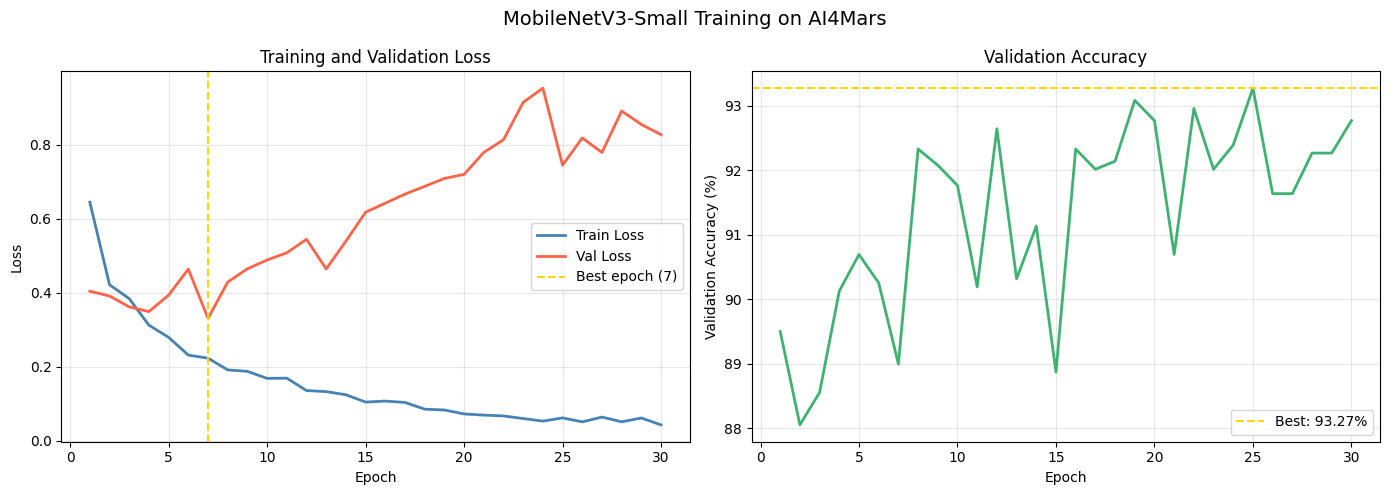

Best val accuracy: 93.27% at epoch 7


In [19]:
# ── Training curves ───────────────────────────────────────────────────────────
HISTORY_PATH = os.path.join(REPO, 'training_history.json')

if os.path.exists(HISTORY_PATH):
    with open(HISTORY_PATH) as f:
        history = json.load(f)

    epochs     = range(1, len(history['train_loss']) + 1)
    best_epoch = int(np.argmin(history['val_loss'])) + 1
    best_acc   = max(history['val_acc']) * 100

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(epochs, history['train_loss'], label='Train Loss', color='steelblue', linewidth=2)
    axes[0].plot(epochs, history['val_loss'],   label='Val Loss',   color='tomato',    linewidth=2)
    axes[0].axvline(best_epoch, color='gold', linestyle='--', label=f'Best epoch ({best_epoch})')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].set_title('Training and Validation Loss')
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    axes[1].plot(epochs, [v*100 for v in history['val_acc']], color='mediumseagreen', linewidth=2)
    axes[1].axhline(best_acc, color='gold', linestyle='--', label=f'Best: {best_acc:.2f}%')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Validation Accuracy (%)')
    axes[1].set_title('Validation Accuracy')
    axes[1].legend(); axes[1].grid(True, alpha=0.3)

    plt.suptitle('MobileNetV3-Small Training on AI4Mars', fontsize=14)
    plt.tight_layout()
    os.makedirs(os.path.join(REPO, 'figures'), exist_ok=True)
    plt.savefig(os.path.join(REPO, 'figures/training_curves.png'), dpi=100, bbox_inches='tight')
    plt.show()
    print(f'Best val accuracy: {best_acc:.2f}% at epoch {best_epoch}')
else:
    print(f'training_history.json not found at {HISTORY_PATH}')

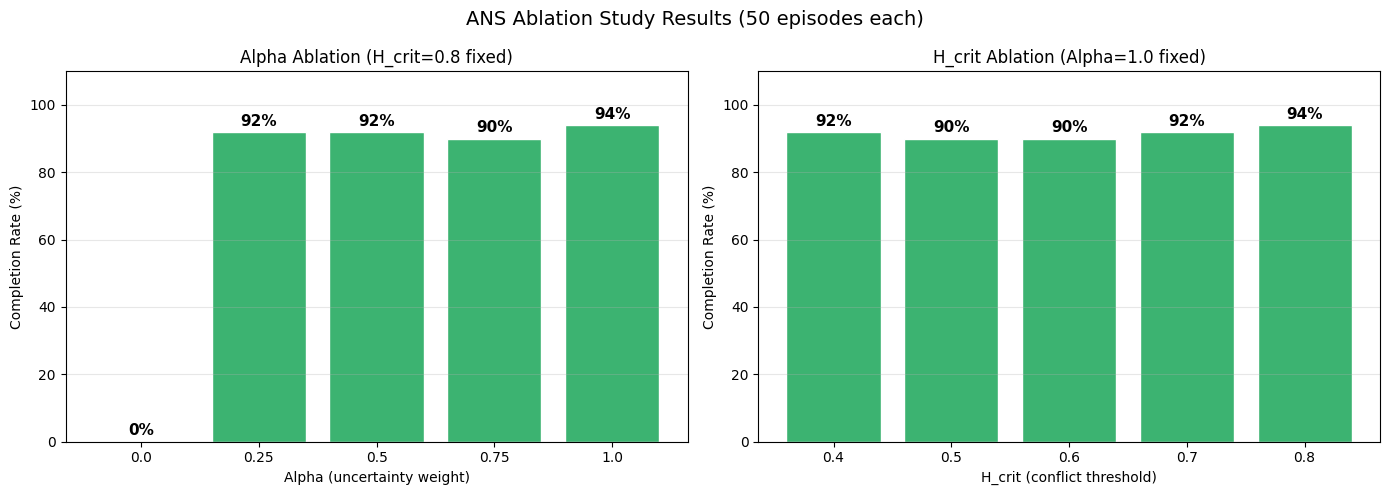

✅ Ablation visualization complete
Optimal: alpha=1.0, completion=94%


In [20]:
# ── Ablation results visualization ───────────────────────────────────────────
ABLATION_PATH = os.path.join(REPO, 'ablation_results.json')

if os.path.exists(ABLATION_PATH):
    with open(ABLATION_PATH) as f:
        ablation = json.load(f)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Alpha sweep
    alphas      = [float(k) for k in ablation['alpha_sweep'].keys()]
    completions = [ablation['alpha_sweep'][k]['completion_rate']*100 for k in ablation['alpha_sweep']]
    rewards     = [ablation['alpha_sweep'][k]['avg_reward'] for k in ablation['alpha_sweep']]
    collisions  = [ablation['alpha_sweep'][k]['avg_collisions'] for k in ablation['alpha_sweep']]

    ax = axes[0]
    color = ['tomato' if c < 50 else 'mediumseagreen' for c in completions]
    bars = ax.bar([str(a) for a in alphas], completions, color=color, edgecolor='white')
    ax.set_xlabel('Alpha (uncertainty weight)'); ax.set_ylabel('Completion Rate (%)')
    ax.set_title('Alpha Ablation (H_crit=0.8 fixed)')
    ax.set_ylim(0, 110); ax.grid(True, alpha=0.3, axis='y')
    for bar, val in zip(bars, completions):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()+1, f'{val:.0f}%',
                ha='center', va='bottom', fontsize=11, fontweight='bold')

    # H_crit sweep
    hcrits      = [float(k) for k in ablation['h_crit_sweep'].keys()]
    completions2 = [ablation['h_crit_sweep'][k]['completion_rate']*100 for k in ablation['h_crit_sweep']]

    ax2 = axes[1]
    color2 = ['tomato' if c < 50 else 'mediumseagreen' for c in completions2]
    bars2 = ax2.bar([str(h) for h in hcrits], completions2, color=color2, edgecolor='white')
    ax2.set_xlabel('H_crit (conflict threshold)'); ax2.set_ylabel('Completion Rate (%)')
    ax2.set_title('H_crit Ablation (Alpha=1.0 fixed)')
    ax2.set_ylim(0, 110); ax2.grid(True, alpha=0.3, axis='y')
    for bar, val in zip(bars2, completions2):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height()+1, f'{val:.0f}%',
                 ha='center', va='bottom', fontsize=11, fontweight='bold')

    plt.suptitle('ANS Ablation Study Results (50 episodes each)', fontsize=14)
    plt.tight_layout()
    plt.savefig(os.path.join(REPO, 'figures/ablation_results.png'), dpi=100, bbox_inches='tight')
    plt.show()
    print('✅ Ablation visualization complete')
    print(f'Optimal: alpha={alphas[np.argmax(completions)]}, completion={max(completions):.0f}%')
else:
    print(f'ablation_results.json not found at {ABLATION_PATH}')

## 7. Summary

In [21]:
# ── Final summary ─────────────────────────────────────────────────────────────
print('=' * 60)
print('ANS PIPELINE VERIFICATION COMPLETE')
print('=' * 60)
print()
print('✅ Dataset loaded and verified')
print('✅ DataLoader shapes correct')
print('✅ get_dominant_label correct')
print('✅ Model forward pass correct')
print('✅ MC Dropout T=30 correct')
print('✅ get_geometry assertions passed')
print('✅ compute_fusion ordering correct')
print('✅ compute_hscore bounds correct')
print('✅ Theta* finds valid path')
print('✅ D* Lite finds valid path')
print('✅ Theta* <= D* Lite path length')
print('✅ MarsRoverEnv step/reset correct')
print('✅ Epsilon decay correct')
print('✅ Trained weights load correctly')
print('✅ Training curves plotted')
print('✅ Ablation results plotted')
print()
print('All systems go.')

ANS PIPELINE VERIFICATION COMPLETE

✅ Dataset loaded and verified
✅ DataLoader shapes correct
✅ get_dominant_label correct
✅ Model forward pass correct
✅ MC Dropout T=30 correct
✅ get_geometry assertions passed
✅ compute_fusion ordering correct
✅ compute_hscore bounds correct
✅ Theta* finds valid path
✅ D* Lite finds valid path
✅ Theta* <= D* Lite path length
✅ MarsRoverEnv step/reset correct
✅ Epsilon decay correct
✅ Trained weights load correctly
✅ Training curves plotted
✅ Ablation results plotted

All systems go.
